In [ ]:
import os
import shutil
import random
import hashlib

import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

import seaborn as sns

In [ ]:
#Download the dataset
!kaggle datasets download jocelyndumlao/colored-flowers-in-bangladesh

Dataset URL: https://www.kaggle.com/datasets/jocelyndumlao/colored-flowers-in-bangladesh
License(s): CC0-1.0
100% 2.71G/2.71G [02:50<00:00, 17.1MB/s]



In [ ]:
#Extract the dataset
import zipfile
zip_path = "/content/colored-flowers-in-bangladesh.zip"

extract_path = "/content/colored-flowers-in-bangladesh"

# Extract the dataset
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [ ]:
dataset_path = "/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD"

In [ ]:
# Automatically detect flower classes

classes = sorted([
    folder
    for folder in os.listdir(dataset_path)
    if os.path.isdir(
        os.path.join(dataset_path, folder)
    )
])

print("Number of classes:", len(classes))

print("\nFlower classes:")

for i, flower in enumerate(classes):

    print(
        f"{i}: {flower}"
    )

Number of classes: 13

Flower classes:
0: Chandramallika
1: Cosmos Phul
2: Gada
3: Golap
4: Jaba
5: Kagoj Phul
6: Noyontara
7: Radhachura
8: Rangan
9: Salvia
10: Sandhyamani
11: Surjomukhi
12: Zinnia


In [ ]:
# Supported image formats

image_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp",
    ".dng"
)


# Count images in each flower class

class_counts = {}

for flower in classes:

    count = 0

    for subclass in ["Single", "Bulk"]:

        folder = os.path.join(
            dataset_path,
            flower,
            subclass
        )

        if not os.path.exists(folder):
            continue

        count += sum(
            file.lower().endswith(
                image_extensions
            )
            for file in os.listdir(folder)
        )

    class_counts[flower] = count


# Display counts

for flower, count in class_counts.items():

    print(
        f"{flower}: {count}"
    )

Chandramallika: 620
Cosmos Phul: 620
Gada: 617
Golap: 605
Jaba: 604
Kagoj Phul: 612
Noyontara: 609
Radhachura: 617
Rangan: 606
Salvia: 634
Sandhyamani: 615
Surjomukhi: 621
Zinnia: 613


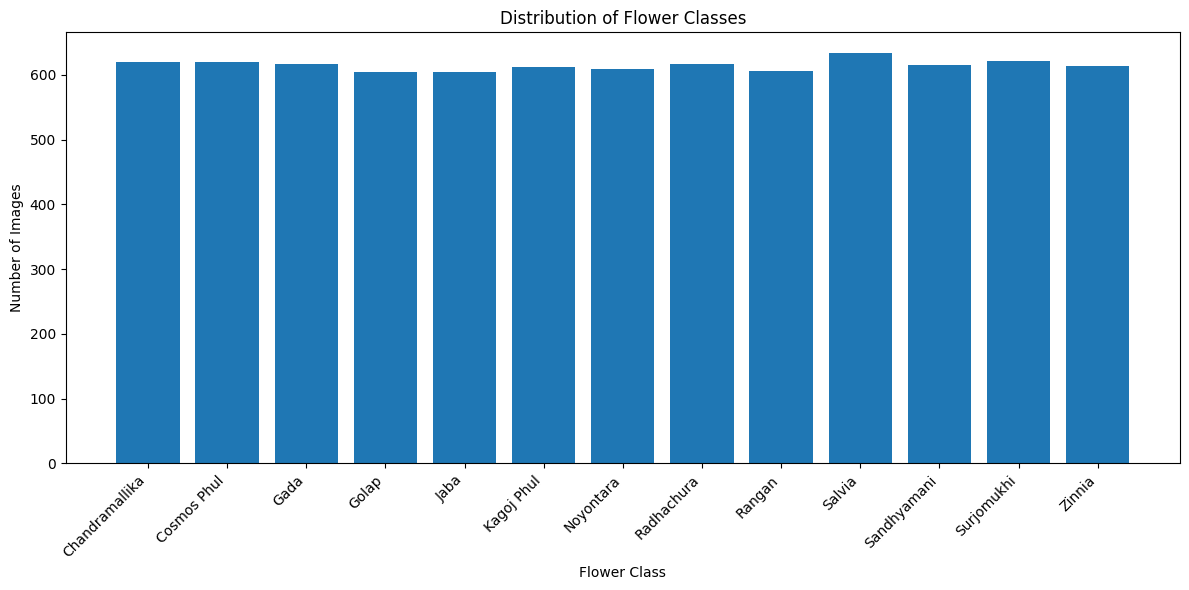

In [ ]:
plt.figure(figsize=(12, 6))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.xlabel("Flower Class")
plt.ylabel("Number of Images")

plt.title(
    "Distribution of Flower Classes"
)

plt.tight_layout()

plt.show()

In [ ]:
# Collect image dimensions

dimensions = []

valid_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)

for flower in classes:

    for subclass in ["Single", "Bulk"]:

        folder = os.path.join(
            dataset_path,
            flower,
            subclass
        )

        if not os.path.exists(folder):
            continue

        for filename in os.listdir(folder):

            if not filename.lower().endswith(
                valid_extensions
            ):
                continue

            image_path = os.path.join(
                folder,
                filename
            )

            try:

                with Image.open(
                    image_path
                ) as img:

                    dimensions.append(
                        img.size
                    )

            except Exception:
                pass


print(
    "Total images checked:",
    len(dimensions)
)

Total images checked: 7989


In [ ]:
from collections import Counter

dimension_counts = Counter(
    dimensions
)

print(
    "Most common dimensions:"
)

for size, count in dimension_counts.most_common(10):

    print(
        size,
        "->",
        count
    )

Most common dimensions:
(720, 720) -> 7989


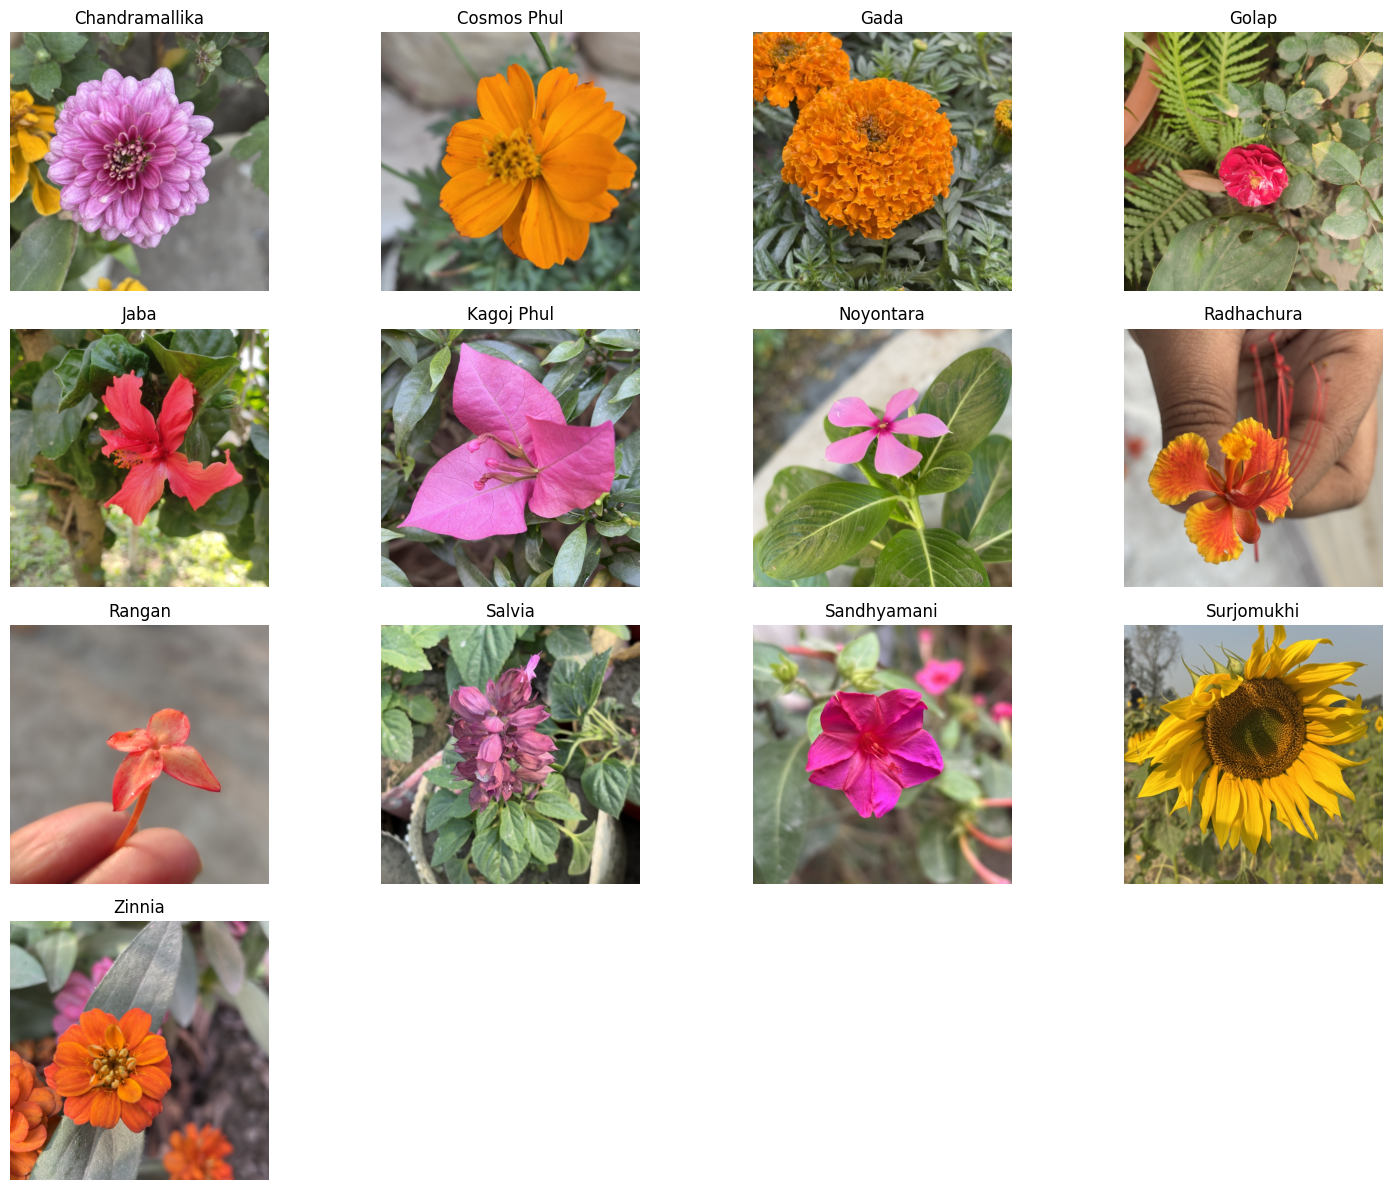

In [ ]:
# Display a few images from each class

plt.figure(
    figsize=(15, 12)
)

plot_index = 1

for flower in classes:

    image_found = False

    for subclass in ["Single", "Bulk"]:

        folder = os.path.join(
            dataset_path,
            flower,
            subclass
        )

        if not os.path.exists(folder):
            continue

        files = [
            f
            for f in os.listdir(folder)
            if f.lower().endswith(
                valid_extensions
            )
        ]

        if len(files) > 0:

            image_path = os.path.join(
                folder,
                files[0]
            )

            try:

                img = Image.open(
                    image_path
                )

                plt.subplot(
                    4,
                    4,
                    plot_index
                )

                plt.imshow(img)

                plt.title(flower)

                plt.axis("off")

                plot_index += 1

                image_found = True

                break

            except Exception:
                pass

plt.tight_layout()

plt.show()

In [ ]:
extensions = Counter()

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        ext = os.path.splitext(file)[1].lower()
        if ext:
            extensions[ext] += 1

print("File types in dataset:")
for ext, count in extensions.items():
    print(f"{ext}: {count}")

File types in dataset:
.jpg: 7989
.dng: 4


In [ ]:
# Find all DNG images

dng_images = []

for flower in classes:

    for subclass in ["Single", "Bulk"]:

        folder = os.path.join(
            dataset_path,
            flower,
            subclass
        )

        if not os.path.exists(folder):
            continue

        for filename in os.listdir(folder):

            if filename.lower().endswith(
                ".dng"
            ):

                dng_images.append(
                    os.path.join(
                        folder,
                        filename
                    )
                )


print(
    "DNG files found:",
    len(dng_images)
)

DNG files found: 4


In [ ]:
!pip install rawpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 71.6 MB/s eta 0:00:00


In [ ]:
import rawpy

# Convert DNG files to JPG

for dng_path in dng_images:

    jpg_path = (
        os.path.splitext(
            dng_path
        )[0]
        + ".jpg"
    )

    try:

        with rawpy.imread(
            dng_path
        ) as raw:

            rgb = raw.postprocess()

        Image.fromarray(
            rgb
        ).save(
            jpg_path,
            quality=95
        )

        print(
            "Converted:",
            os.path.basename(
                dng_path
            )
        )

    except Exception as e:

        print(
            "Conversion failed:",
            dng_path
        )

        print(e)

Converted: IMG_20250111_112520.dng
Converted: IMG_20250111_112523.dng
Converted: IMG_20250111_112617.dng
Converted: IMG_20250111_112515.dng


In [ ]:
# Remove DNG only if JPG conversion succeeded

for dng_path in dng_images:

    jpg_path = (
        os.path.splitext(
            dng_path
        )[0]
        + ".jpg"
    )

    if os.path.exists(jpg_path):

        os.remove(dng_path)

print(
    "DNG cleanup completed."
)

DNG cleanup completed.


In [ ]:
# Check every supported image

corrupted_images = []

for flower in classes:

    for subclass in ["Single", "Bulk"]:

        folder = os.path.join(
            dataset_path,
            flower,
            subclass
        )

        if not os.path.exists(folder):
            continue

        for filename in os.listdir(folder):

            if not filename.lower().endswith(
                valid_extensions
            ):
                continue

            image_path = os.path.join(
                folder,
                filename
            )

            try:

                with Image.open(
                    image_path
                ) as img:

                    img.verify()

            except Exception:

                corrupted_images.append(
                    image_path
                )


print(
    "Corrupted images:",
    len(corrupted_images)
)

Corrupted images: 0


In [ ]:
from collections import defaultdict

# Store image hashes

image_hashes = defaultdict(list)

for flower in classes:

    for subclass in ["Single", "Bulk"]:

        folder = os.path.join(
            dataset_path,
            flower,
            subclass
        )

        if not os.path.exists(folder):
            continue

        for filename in os.listdir(folder):

            if not filename.lower().endswith(
                valid_extensions
            ):
                continue

            image_path = os.path.join(
                folder,
                filename
            )

            try:

                with open(
                    image_path,
                    "rb"
                ) as f:

                    file_hash = hashlib.md5(
                        f.read()
                    ).hexdigest()

                image_hashes[
                    file_hash
                ].append(
                    image_path
                )

            except Exception:
                pass


duplicates = {
    h: paths
    for h, paths in image_hashes.items()
    if len(paths) > 1
}

print(
    "Duplicate groups:",
    len(duplicates)
)

Duplicate groups: 17



Duplicate Group 1
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Gada/Bulk/IMG_0844.jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Gada/Bulk/IMG_0844(1).jpg


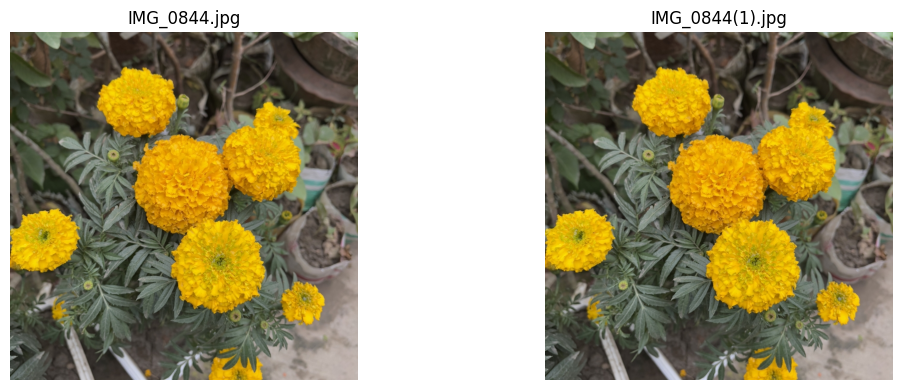


Duplicate Group 2
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Golap/Single/IMG_1773.JPG
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Golap/Single/IMG_1773(1).JPG


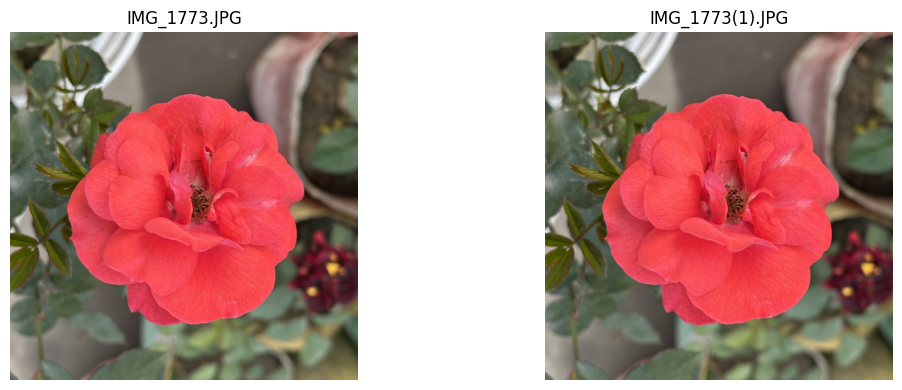


Duplicate Group 3
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Golap/Bulk/IMG_1763(1).JPG
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Golap/Bulk/IMG_1763.JPG


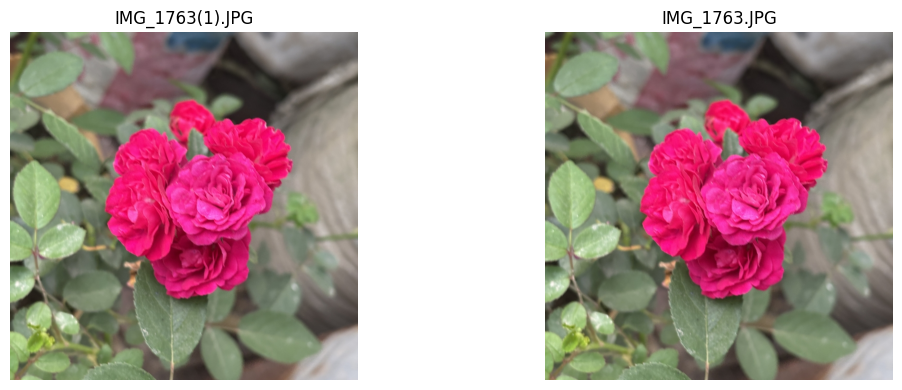


Duplicate Group 4
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113204.jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113204(1).jpg


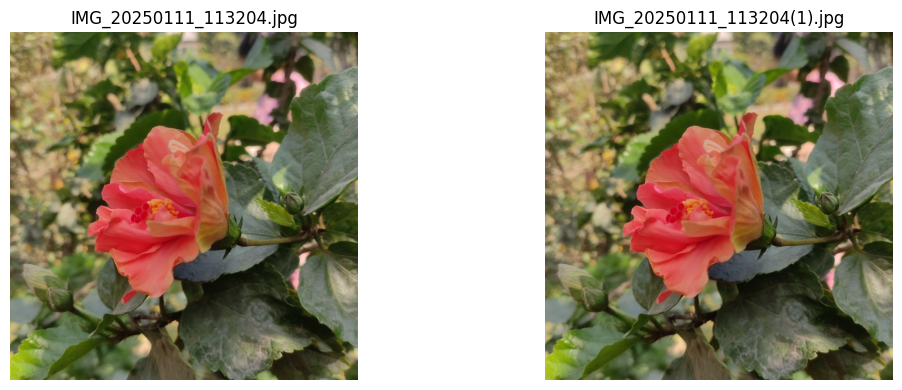


Duplicate Group 5
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113201(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113201.jpg


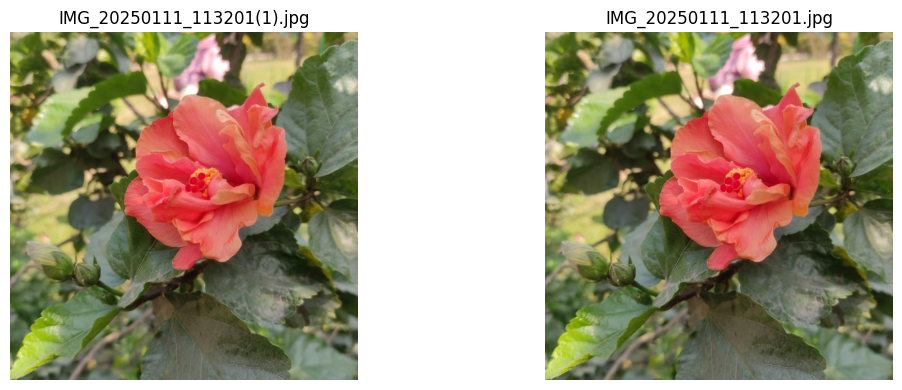


Duplicate Group 6
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113125.jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113125(1).jpg


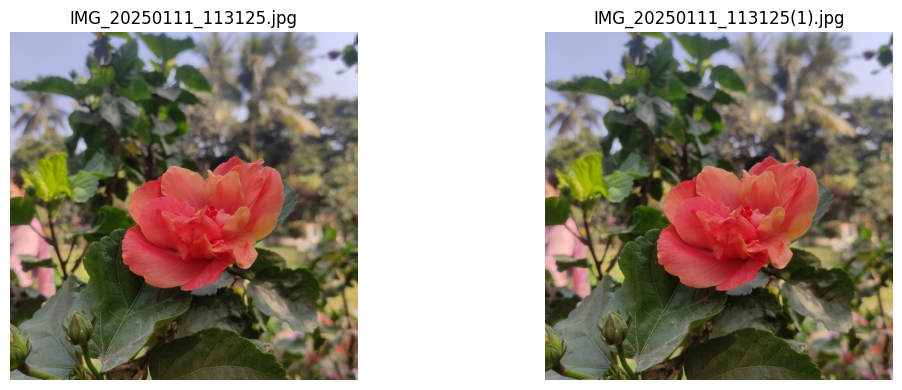


Duplicate Group 7
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113119(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113119.jpg


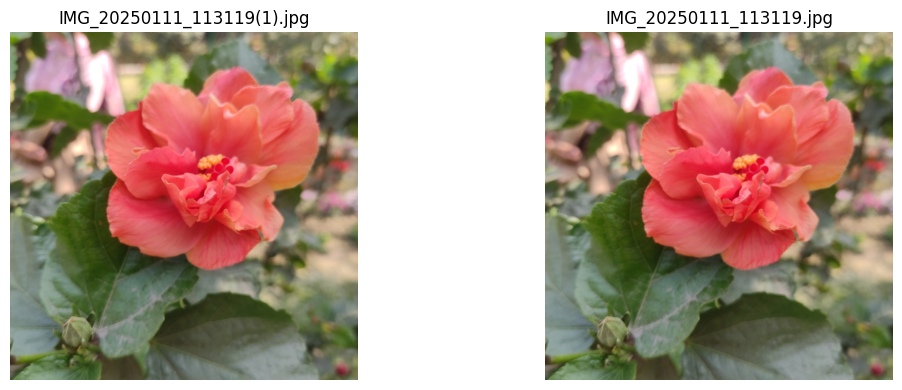


Duplicate Group 8
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113055.jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113055(1).jpg


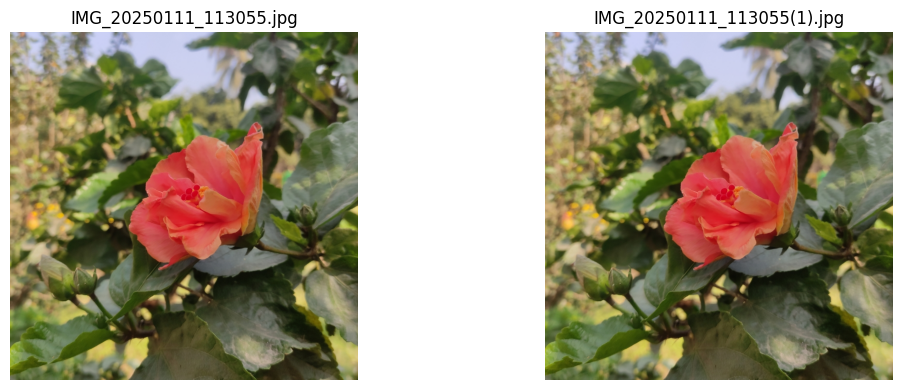


Duplicate Group 9
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_141510(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_141510.jpg


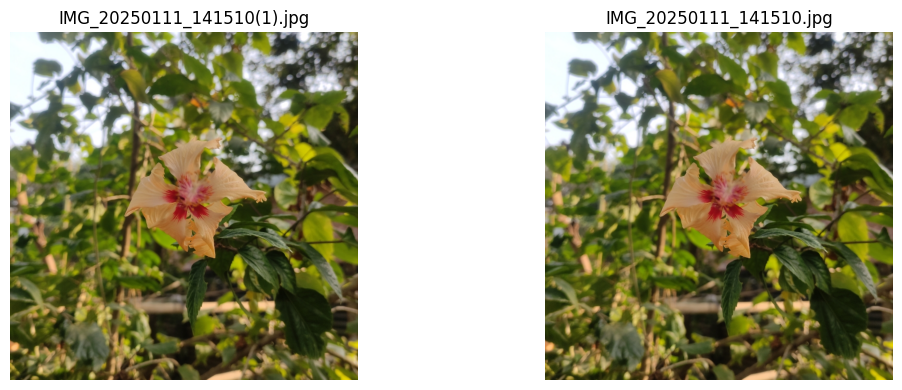


Duplicate Group 10
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113033.jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113033(1).jpg


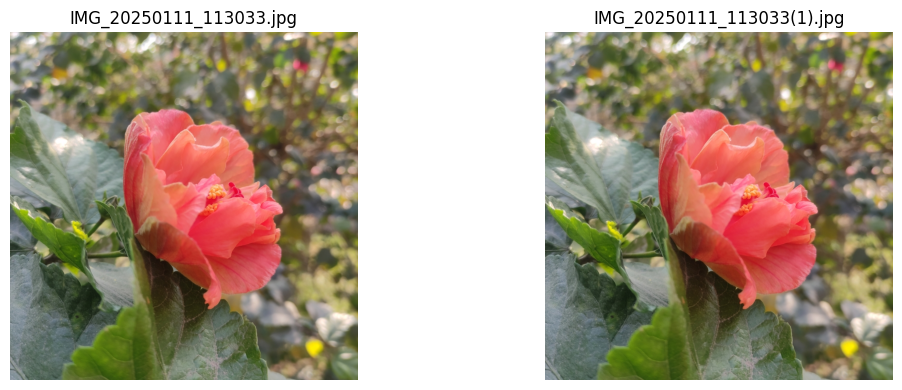


Duplicate Group 11
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113112(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113112.jpg


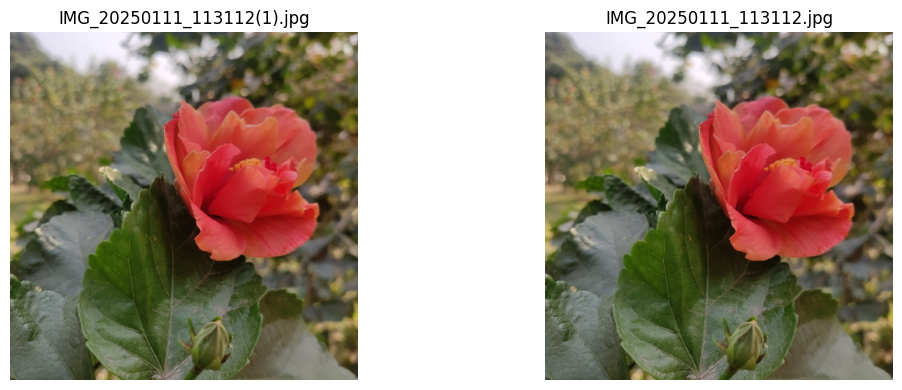


Duplicate Group 12
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113046(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113046.jpg


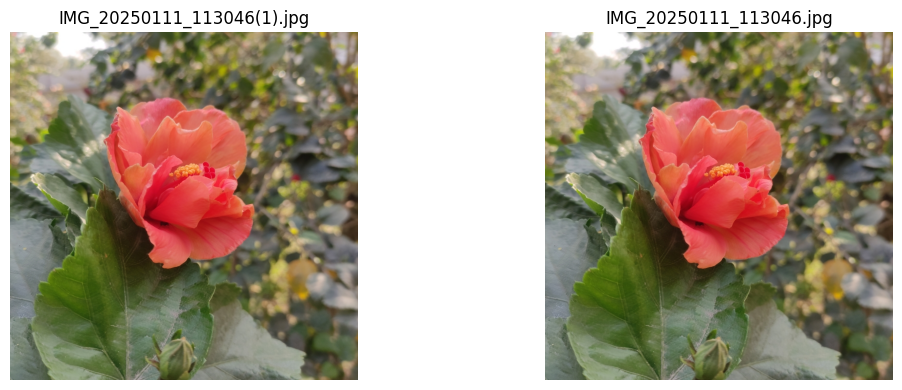


Duplicate Group 13
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113022.jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113022(1).jpg


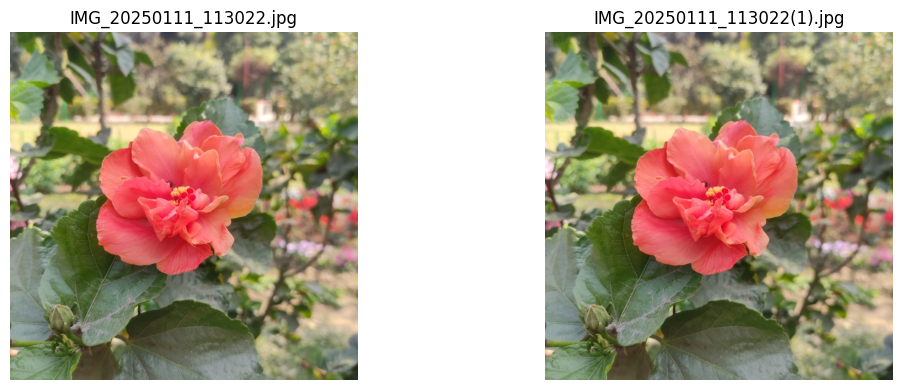


Duplicate Group 14
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113229(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_113229.jpg


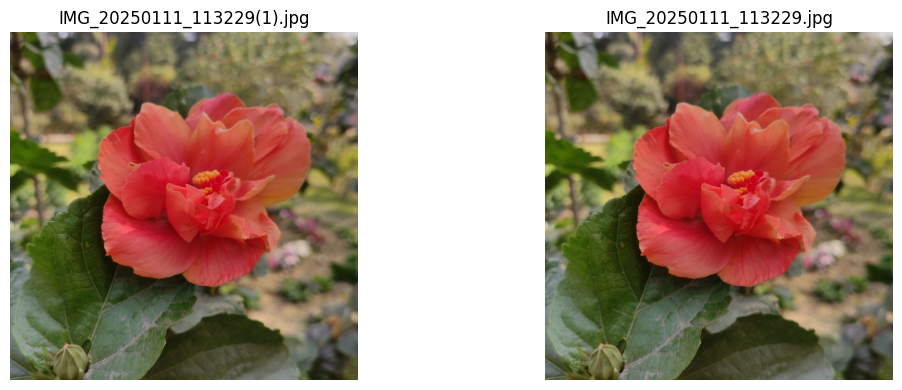


Duplicate Group 15
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_121314(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_121314.jpg


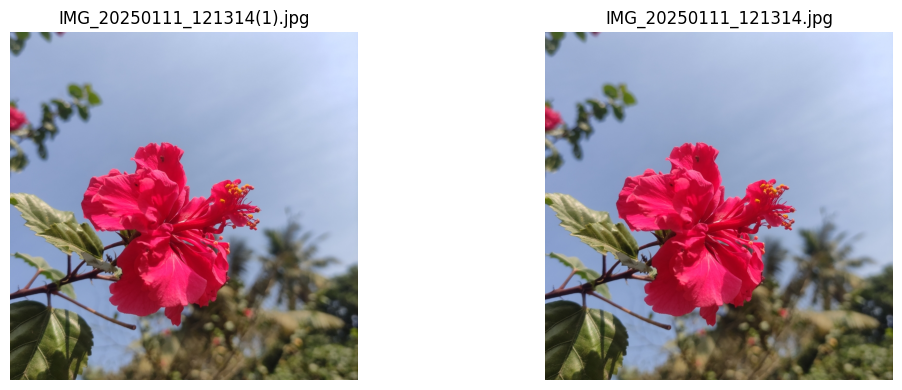


Duplicate Group 16
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_121317(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Jaba/Single/IMG_20250111_121317.jpg


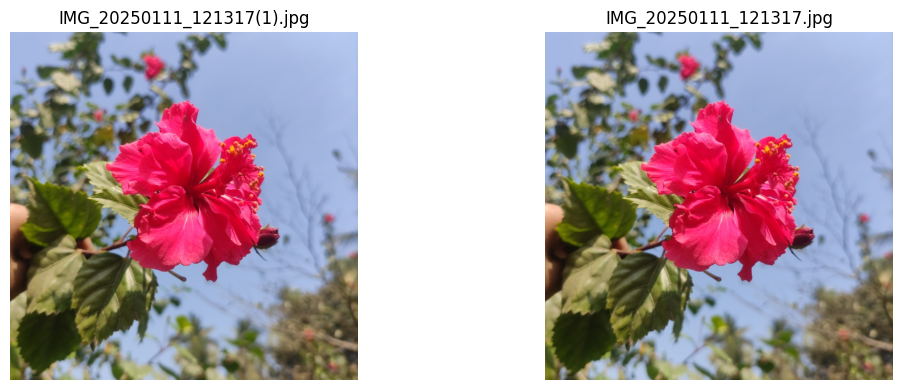


Duplicate Group 17
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Sandhyamani/Bulk/IMG_2916(1).jpg
/content/colored-flowers-in-bangladesh/ColoredFlowersBD A Comphrehensive Image Dataset of Colored Flowers in Bangladesh for Identification and Classification Using Machine Learning and Computer Vision/ColoredFlowersBD/ColoredFlowersBD/Sandhyamani/Bulk/IMG_2916.jpg


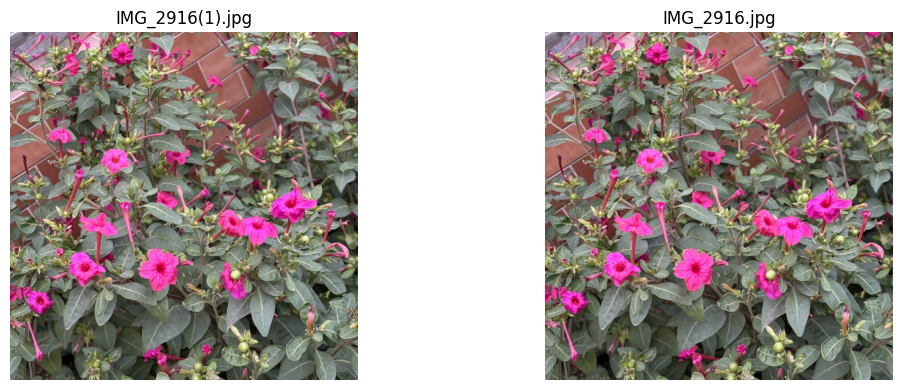

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

for group_number, (file_hash, paths) in enumerate(duplicates.items(), start=1):

    print(f"\nDuplicate Group {group_number}")

    # Show file paths
    for path in paths:
        print(path)

    # Create a figure
    plt.figure(figsize=(12, 4))

    for i, path in enumerate(paths):
        try:
            img = Image.open(path)

            plt.subplot(1, len(paths), i + 1)
            plt.imshow(img)
            plt.title(os.path.basename(path))
            plt.axis("off")

        except Exception as e:
            print("Could not open:", path)

    plt.tight_layout()
    plt.show()

In [ ]:
# Keep one copy and remove the others

for file_hash, paths in duplicates.items():

    for duplicate_path in paths[1:]:

        os.remove(
            duplicate_path
        )

print(
    "Duplicate cleanup completed."
)

Duplicate cleanup completed.


In [ ]:
# Count the final cleaned dataset

final_counts = {}

for flower in classes:

    count = 0

    for subclass in ["Single", "Bulk"]:

        folder = os.path.join(
            dataset_path,
            flower,
            subclass
        )

        if not os.path.exists(folder):
            continue

        count += sum(
            file.lower().endswith(
                valid_extensions
            )
            for file in os.listdir(folder)
        )

    final_counts[flower] = count


print("Final cleaned dataset:")

for flower, count in final_counts.items():

    print(
        f"{flower}: {count}"
    )


cleaned_total = sum(
    final_counts.values()
)

print(
    "\nTotal cleaned images:",
    cleaned_total
)

Final cleaned dataset:
Chandramallika: 620
Cosmos Phul: 620
Gada: 616
Golap: 603
Jaba: 591
Kagoj Phul: 612
Noyontara: 609
Radhachura: 617
Rangan: 606
Salvia: 634
Sandhyamani: 614
Surjomukhi: 621
Zinnia: 613

Total cleaned images: 7976


In [ ]:
# Directory for the final dataset split

split_path = "/content/flower_dataset"

# Create fresh folders

for split in [
    "train",
    "validation",
    "test"
]:

    os.makedirs(
        os.path.join(
            split_path,
            split
        ),
        exist_ok=True
    )


# Reproducible splitting

random.seed(42)

print(
    "Fresh split directory created."
)

Fresh split directory created.


In [ ]:
# 80% training
# 10% validation
# 10% testing

split_extensions = (
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
)


split_summary = {}


for flower in classes:

    images = []

    flower_path = os.path.join(
        dataset_path,
        flower
    )


    # Collect images from Single and Bulk

    for subclass in [
        "Single",
        "Bulk"
    ]:

        folder = os.path.join(
            flower_path,
            subclass
        )

        if not os.path.exists(folder):
            continue

        for filename in os.listdir(
            folder
        ):

            if filename.lower().endswith(
                split_extensions
            ):

                images.append(
                    (
                        os.path.join(
                            folder,
                            filename
                        ),
                        subclass
                    )
                )


    # Shuffle images

    random.shuffle(
        images
    )


    total = len(images)

    train_end = int(
        total * 0.80
    )

    validation_end = (
        train_end +
        int(total * 0.10)
    )


    train_images = images[
        :train_end
    ]

    validation_images = images[
        train_end:validation_end
    ]

    test_images = images[
        validation_end:
    ]


    # Save counts

    split_summary[flower] = {

        "total": total,

        "train": len(
            train_images
        ),

        "validation": len(
            validation_images
        ),

        "test": len(
            test_images
        )
    }


    # Create class folders

    for split in [
        "train",
        "validation",
        "test"
    ]:

        os.makedirs(
            os.path.join(
                split_path,
                split,
                flower
            ),
            exist_ok=True
        )


    # Copy images safely

    def copy_images(
        image_list,
        split
    ):

        for image_path, subclass in image_list:

            original_filename = (
                os.path.basename(
                    image_path
                )
            )


            # Add Single/Bulk prefix.
            # This prevents filename collisions.

            new_filename = (
                f"{subclass}_"
                f"{original_filename}"
            )


            destination = os.path.join(
                split_path,
                split,
                flower,
                new_filename
            )


            shutil.copy2(
                image_path,
                destination
            )


    copy_images(
        train_images,
        "train"
    )

    copy_images(
        validation_images,
        "validation"
    )

    copy_images(
        test_images,
        "test"
    )


# Print split information

for flower, counts in split_summary.items():

    print(
        f"{flower}: "
        f"Train={counts['train']}, "
        f"Validation={counts['validation']}, "
        f"Test={counts['test']}"
    )

Chandramallika: Train=496, Validation=62, Test=62
Cosmos Phul: Train=496, Validation=62, Test=62
Gada: Train=492, Validation=61, Test=63
Golap: Train=482, Validation=60, Test=61
Jaba: Train=472, Validation=59, Test=60
Kagoj Phul: Train=489, Validation=61, Test=62
Noyontara: Train=487, Validation=60, Test=62
Radhachura: Train=493, Validation=61, Test=63
Rangan: Train=484, Validation=60, Test=62
Salvia: Train=507, Validation=63, Test=64
Sandhyamani: Train=491, Validation=61, Test=62
Surjomukhi: Train=496, Validation=62, Test=63
Zinnia: Train=490, Validation=61, Test=62


In [ ]:
def count_images(folder):

    count = 0

    for root, dirs, files in os.walk(
        folder
    ):

        for file in files:

            if file.lower().endswith(
                split_extensions
            ):

                count += 1

    return count


train_count = count_images(
    os.path.join(
        split_path,
        "train"
    )
)

validation_count = count_images(
    os.path.join(
        split_path,
        "validation"
    )
)

test_count = count_images(
    os.path.join(
        split_path,
        "test"
    )
)


split_total = (
    train_count +
    validation_count +
    test_count
)


print(
    "Train:",
    train_count
)

print(
    "Validation:",
    validation_count
)

print(
    "Test:",
    test_count
)

print(
    "Split total:",
    split_total
)

print(
    "Cleaned source total:",
    cleaned_total
)


# Important verification

assert (
    split_total ==
    cleaned_total
), "ERROR: Split total does not match cleaned dataset total!"

print(
    "\nDataset split verified successfully."
)

Train: 6375
Validation: 793
Test: 808
Split total: 7976
Cleaned source total: 7976

Dataset split verified successfully.


In [ ]:
IMG_SIZE = (224, 224)

BATCH_SIZE = 32

SEED = 42


# Training dataset

train_ds = tf.keras.utils.image_dataset_from_directory(

    os.path.join(
        split_path,
        "train"
    ),

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=True,

    seed=SEED
)


# Validation dataset

validation_ds = tf.keras.utils.image_dataset_from_directory(

    os.path.join(
        split_path,
        "validation"
    ),

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)


# Test dataset

test_ds = tf.keras.utils.image_dataset_from_directory(

    os.path.join(
        split_path,
        "test"
    ),

    image_size=IMG_SIZE,

    batch_size=BATCH_SIZE,

    shuffle=False
)

Found 6375 files belonging to 13 classes.
Found 793 files belonging to 13 classes.
Found 808 files belonging to 13 classes.


In [ ]:
class_names = train_ds.class_names

num_classes = len(
    class_names
)

print(
    "Number of classes:",
    num_classes
)

print(
    "\nClasses:"
)

for i, name in enumerate(
    class_names
):

    print(
        i,
        "-",
        name
    )


# Make sure all datasets
# use the same class order

assert (
    train_ds.class_names
    ==
    validation_ds.class_names
)

assert (
    train_ds.class_names
    ==
    test_ds.class_names
)

print(
    "\nClass order verified."
)

Number of classes: 13

Classes:
0 - Chandramallika
1 - Cosmos Phul
2 - Gada
3 - Golap
4 - Jaba
5 - Kagoj Phul
6 - Noyontara
7 - Radhachura
8 - Rangan
9 - Salvia
10 - Sandhyamani
11 - Surjomukhi
12 - Zinnia

Class order verified.


In [ ]:
# Convert pixel values:
# 0-255 → 0-1

normalization_layer = (
    tf.keras.layers.Rescaling(
        1.0 / 255
    )
)


train_ds = train_ds.map(

    lambda x, y:
    (
        normalization_layer(x),
        y
    ),

    num_parallel_calls=(
        tf.data.AUTOTUNE
    )
)


validation_ds = validation_ds.map(

    lambda x, y:
    (
        normalization_layer(x),
        y
    ),

    num_parallel_calls=(
        tf.data.AUTOTUNE
    )
)


test_ds = test_ds.map(

    lambda x, y:
    (
        normalization_layer(x),
        y
    ),

    num_parallel_calls=(
        tf.data.AUTOTUNE
    )
)

In [ ]:
data_augmentation = tf.keras.Sequential([

    # Horizontal flipping
    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    # Small rotation
    tf.keras.layers.RandomRotation(
        0.1
    ),

    # Small zoom
    tf.keras.layers.RandomZoom(
        0.1
    )
])
# Apply augmentation only to training data

train_ds = train_ds.map(

    lambda x, y:
    (
        data_augmentation(
            x,
            training=True
        ),
        y
    ),

    num_parallel_calls=(
        tf.data.AUTOTUNE
    )
)

In [ ]:
#Prefetch data
# Improve the input pipeline performance

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(
    AUTOTUNE
)

validation_ds = validation_ds.prefetch(
    AUTOTUNE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)

In [ ]:
# Create the CNN model

model = tf.keras.Sequential([

    # Input image: 224 × 224 RGB
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1

    tf.keras.layers.Conv2D(32,(3, 3),padding="same", activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 2

    tf.keras.layers.Conv2D(64, (3, 3), padding="same",activation="relu"),

    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    tf.keras.layers.Conv2D( 128,(3, 3),padding="same",activation="relu"),

    tf.keras.layers.MaxPooling2D((2, 2)),

    # Reduce feature maps
    # without a huge Flatten layer

    tf.keras.layers.GlobalAveragePooling2D(),


    # Classification layer

    tf.keras.layers.Dense(128,activation="relu"),

    tf.keras.layers.Dropout(0.5),

    # 13-class output

    tf.keras.layers.Dense(num_classes,activation="softmax")
])


model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,437 (435.30 KB)

 Trainable params: 111,437 (435.30 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",loss=("sparse_categorical_crossentropy" ),metrics=["accuracy"])

print(
    "Model compiled successfully."
)

Model compiled successfully.


In [ ]:
# Stop training when validation
# performance stops improving

early_stopping = (
    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        patience=3,

        restore_best_weights=True
    )
)

In [ ]:
history = model.fit(

    train_ds,

    validation_data=validation_ds,

    epochs=20,

    callbacks=[
        early_stopping
    ]
)

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 106s 477ms/step - accuracy: 0.2209 - loss: 2.1870 - val_accuracy: 0.3506 - val_loss: 1.7529
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 130s 458ms/step - accuracy: 0.4435 - loss: 1.5486 - val_accuracy: 0.6103 - val_loss: 1.1510
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 141s 454ms/step - accuracy: 0.5360 - loss: 1.2650 - val_accuracy: 0.6532 - val_loss: 1.0349
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 92s 459ms/step - accuracy: 0.6100 - loss: 1.0915 - val_accuracy: 0.7364 - val_loss: 0.8152
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 141s 452ms/step - accuracy: 0.6541 - loss: 0.9815 - val_accuracy: 0.7692 - val_loss: 0.7164
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 91s 455ms/step - accuracy: 0.6866 - loss: 0.8829 - val_accuracy: 0.7781 - val_loss: 0.6844
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 90s 446ms/step - accuracy: 0.6987 - loss: 0.8192 - val_accuracy: 0.8008 - val_loss: 0.6020
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 150s 488ms/step - accuracy: 0.7136 - lo

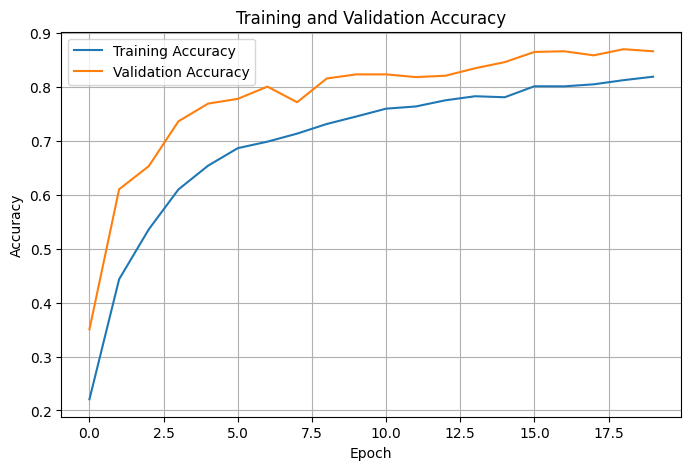

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Accuracy"
)

plt.title(
    "Training and Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

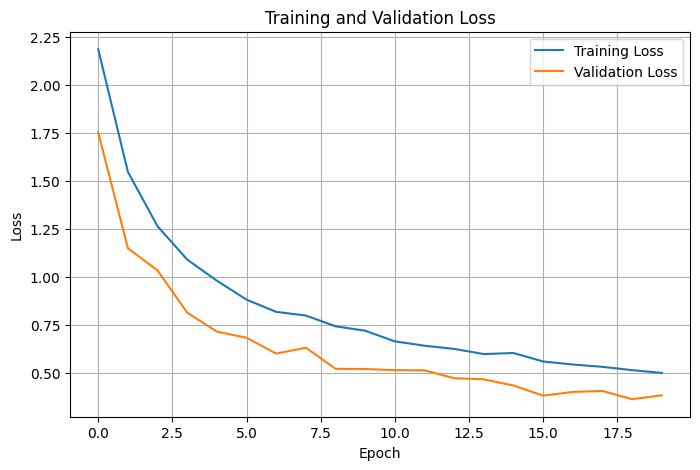

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

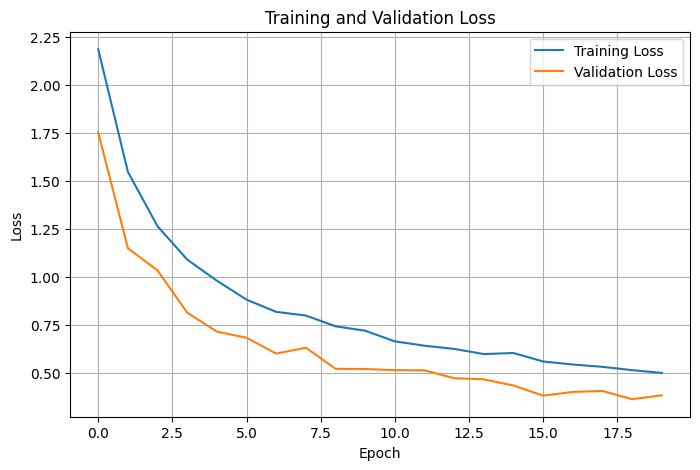

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel(
    "Epoch"
)

plt.ylabel(
    "Loss"
)

plt.title(
    "Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(
    test_ds
)

print(
    "Test Loss:",
    test_loss
)

print(
    "Test Accuracy:",
    test_accuracy
)

26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 230ms/step - accuracy: 0.8960 - loss: 0.3425
Test Loss: 0.3425346314907074
Test Accuracy: 0.896039605140686


In [ ]:
# Store actual and predicted labels

y_true = []

y_pred = []


for images, labels in test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels.numpy()
    )

    y_pred.extend(
        predicted_labels
    )


y_true = np.array(
    y_true
)

y_pred = np.array(
    y_pred
)

In [ ]:
print(
    classification_report(

        y_true,

        y_pred,

        target_names=class_names
    )
)

                precision    recall  f1-score   support

Chandramallika       0.89      0.81      0.85        62
   Cosmos Phul       0.84      0.76      0.80        62
          Gada       0.75      0.86      0.80        63
         Golap       0.90      0.74      0.81        61
          Jaba       0.92      0.93      0.93        60
    Kagoj Phul       0.95      0.94      0.94        62
     Noyontara       0.95      0.98      0.97        62
    Radhachura       1.00      0.92      0.96        63
        Rangan       0.88      0.98      0.93        62
        Salvia       0.95      0.98      0.97        64
   Sandhyamani       0.93      0.85      0.89        62
    Surjomukhi       0.93      1.00      0.96        63
        Zinnia       0.79      0.89      0.83        62

      accuracy                           0.90       808
     macro avg       0.90      0.90      0.90       808
  weighted avg       0.90      0.90      0.90       808



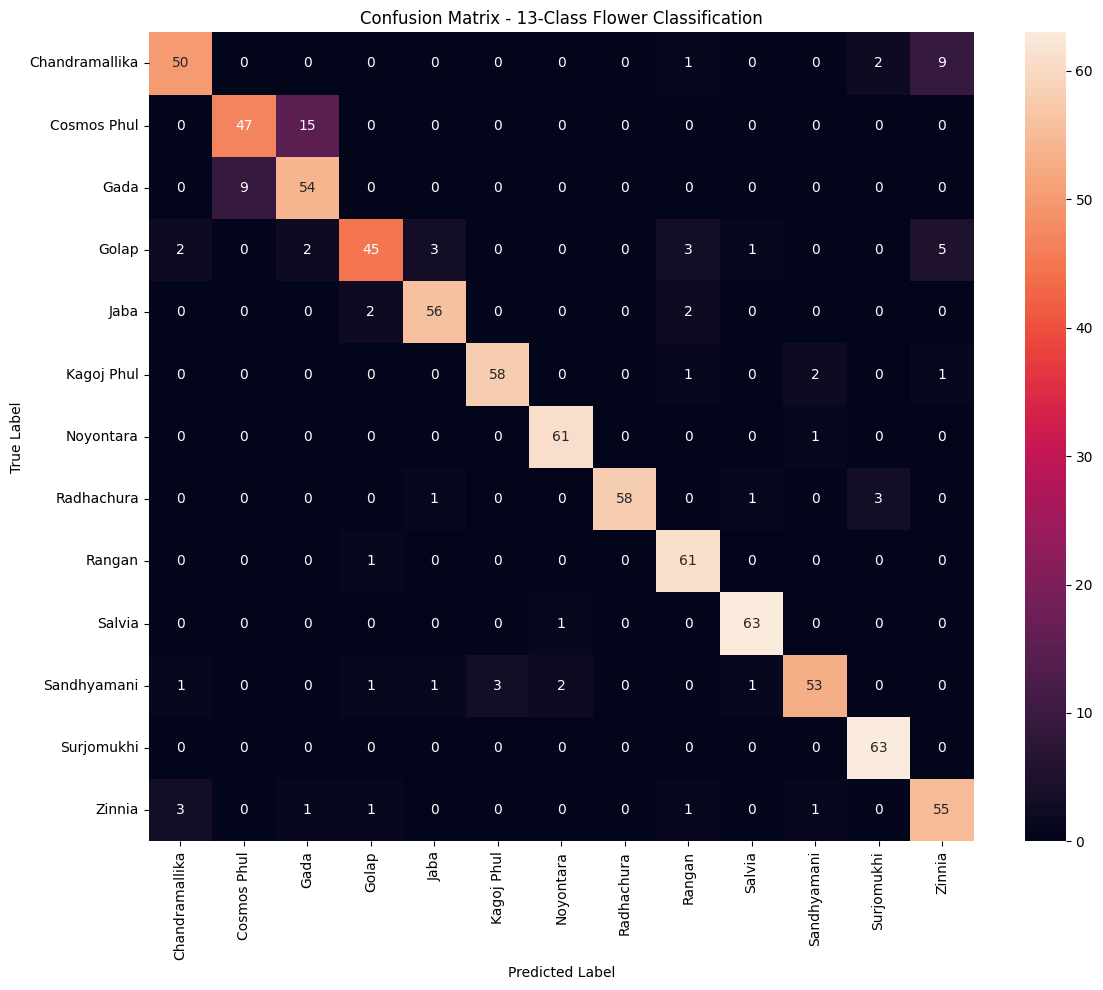

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)


plt.figure(
    figsize=(12, 10)
)


sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names
)


plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.title(
    "Confusion Matrix - 13-Class Flower Classification"
)

plt.tight_layout()

plt.show()

In [ ]:
# Save the trained CNN

model.save(
    "/content/flower_cnn_model.keras"
)

print(
    "Model saved successfully."
)

Model saved successfully.
